# **Importing Libraries**

In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [5]:
import pandas as pd
from datetime import datetime
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
# Shows plots in jupyter notebook
%matplotlib inline

# Set plot style
#sns.set(color_codes=True)

# Loading File From Source

In [8]:
client_df = pd.read_csv(r"C:\Users\USER\Desktop\BCGX_Data_Science\clean_data_after_eda.csv")
client_df["date_activ"] = pd.to_datetime(client_df["date_activ"], format='%Y-%m-%d')
client_df["date_end"] = pd.to_datetime(client_df["date_end"], format='%Y-%m-%d')
client_df["date_modif_prod"] = pd.to_datetime(client_df["date_modif_prod"], format='%Y-%m-%d')
client_df["date_renewal"] = pd.to_datetime(client_df["date_renewal"], format='%Y-%m-%d')

In [21]:
#client_df.drop(columns=['id'], inplace=True)
client_df.head()

,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,forecast_cons_year,...,var_6m_price_off_peak_var,var_6m_price_peak_var,var_6m_price_mid_peak_var,var_6m_price_off_peak_fix,var_6m_price_peak_fix,var_6m_price_mid_peak_fix,var_6m_price_off_peak,var_6m_price_peak,var_6m_price_mid_peak,churn
0,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,0,...,0.000131,4.100838e-05,9.084737e-04,2.086294,99.530517,44.235794,2.086425,9.953056e+01,4.423670e+01,1
1,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,0,...,0.000003,1.217891e-03,0.000000e+00,0.009482,0.000000,0.000000,0.009485,1.217891e-03,0.000000e+00,0
2,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.96,0,...,0.000004,9.450150e-08,0.000000e+00,0.000000,0.000000,0.000000,0.000004,9.450150e-08,0.000000e+00,0
3,lmkebamcaaclubfxadlmueccxoimlema,1584,0,0,2010-03-30,2016-03-30,2010-03-30,2015-03-31,240.04,0,...,0.000003,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000003,0.000000e+00,0.000000e+00,0
4,MISSING,4425,0,526,2010-01-13,2016-03-07,2010-01-13,2015-03-09,445.75,526,...,0.000011,2.896760e-06,4.860000e-10,0.000000,0.000000,0.000000,0.000011,2.896760e-06,4.860000e-10,0


In [13]:
client_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14606 entries, 0 to 14605
Data columns (total 43 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   channel_sales                   14606 non-null  object        
 1   cons_12m                        14606 non-null  int64         
 2   cons_gas_12m                    14606 non-null  int64         
 3   cons_last_month                 14606 non-null  int64         
 4   date_activ                      14606 non-null  datetime64[ns]
 5   date_end                        14606 non-null  datetime64[ns]
 6   date_modif_prod                 14606 non-null  datetime64[ns]
 7   date_renewal                    14606 non-null  datetime64[ns]
 8   forecast_cons_12m               14606 non-null  float64       
 9   forecast_cons_year              14606 non-null  int64         
 10  forecast_discount_energy        14606 non-null  float64       
 11  fo

In [19]:
price_df = pd.read_csv(r"C:\Users\USER\Desktop\BCGX_Data_Science\price-data.csv")
price_df["price_date"] = pd.to_datetime(price_df["price_date"], format='%Y-%m-%d')
#price_df.drop(columns=['id'], inplace=True)
price_df.head()

,id,price_date,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
0,038af19179925da21a25619c5a24b745,2015-01-01,0.151367,0.0,0.0,44.266931,0.0,0.0
1,038af19179925da21a25619c5a24b745,2015-02-01,0.151367,0.0,0.0,44.266931,0.0,0.0
2,038af19179925da21a25619c5a24b745,2015-03-01,0.151367,0.0,0.0,44.266931,0.0,0.0
3,038af19179925da21a25619c5a24b745,2015-04-01,0.149626,0.0,0.0,44.266931,0.0,0.0
4,038af19179925da21a25619c5a24b745,2015-05-01,0.149626,0.0,0.0,44.266931,0.0,0.0


# **Feature Engineering**
Here, suitable features are determine which can be used in predicting churn rate.

In [18]:
# Group off-peak prices by companies and month
monthly_price_by_id = price_df.groupby(['id', 'price_date']).agg({'price_off_peak_var': 'mean', 'price_off_peak_fix': 'mean'}).reset_index()

# Get january and december prices
jan_prices = monthly_price_by_id.groupby('id').first().reset_index()
dec_prices = monthly_price_by_id.groupby('id').last().reset_index()

# Calculate the difference
diff = pd.merge(dec_prices.rename(columns={'price_off_peak_var': 'dec_1', 'price_off_peak_fix': 'dec_2'}), jan_prices.drop(columns='price_date'), on='id')
diff['offpeak_diff_dec_january_energy'] = diff['dec_1'] - diff['price_off_peak_var']
diff['offpeak_diff_dec_january_power'] = diff['dec_2'] - diff['price_off_peak_fix']
diff = diff[['id', 'offpeak_diff_dec_january_energy','offpeak_diff_dec_january_power']]
diff.head()

KeyError: 'id'

# Mean Prices for each Period

In [ ]:
price_columns = [
    "price_off_peak_var", "price_peak_var", "price_mid_peak_var",
    "price_off_peak_fix", "price_peak_fix", "price_mid_peak_fix"
]

# Calculate the mean for each price column
mean_prices = price_df[price_columns].mean()

print("Mean Prices for Price Features:")
print(mean_prices)


Mean Prices for Price Features:
price_off_peak_var     0.141027
price_peak_var         0.054630
price_mid_peak_var     0.030496
price_off_peak_fix    43.334477
price_peak_fix        10.622875
price_mid_peak_fix     6.409984
dtype: float64


# Differences in the mean Price for each Period

In [ ]:
# Calculate the price differences between variable and fixed prices for each period
price_df['diff_off_peak'] = price_df['price_off_peak_var'] - price_df['price_off_peak_fix']
price_df['diff_peak'] = price_df['price_peak_var'] - price_df['price_peak_fix']
price_df['diff_mid_peak'] = price_df['price_mid_peak_var'] - price_df['price_mid_peak_fix']

# Calculate the mean price difference for each period
mean_diff_off_peak = price_df['diff_off_peak'].mean()
mean_diff_peak = price_df['diff_peak'].mean()
mean_diff_mid_peak = price_df['diff_mid_peak'].mean()

# Display the results
print("Mean Price Difference (Variable - Fixed):")
print(f"Off Peak: {mean_diff_off_peak:.4f}")
print(f"Peak: {mean_diff_peak:.4f}")
print(f"Mid Peak: {mean_diff_mid_peak:.4f}")


Mean Price Difference (Variable - Fixed):
Off Peak: -43.1934
Peak: -10.5682
Mid Peak: -6.3795


# Computation of Tenure in relation to Churn

In [ ]:
# Calculate tenure in days
client_df['tenure'] = (client_df['date_end'] - client_df['date_activ']).dt.days

# Calculate the mean tenure for churned and non-churned customers
#mean_tenure_by_churn = client_df.groupby('churn')['tenure'].mean()
mean_tenure_by_churn = client_df.groupby(['tenure']).agg({'churn': 'mean'}).sort_values(by='churn', ascending=False)
print("Mean tenure by churn status:")
print(mean_tenure_by_churn)


Mean tenure by churn status:
        churn
tenure       
3334      1.0
2343      1.0
1276      1.0
1703      1.0
1212      1.0
...       ...
1822      0.0
1820      0.0
1818      0.0
1817      0.0
4795      0.0

[1410 rows x 1 columns]


In [ ]:
price_df.drop(columns=["price_date",]).head()

,id,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix,diff_off_peak,diff_peak,diff_mid_peak
0,038af19179925da21a25619c5a24b745,0.151367,0.0,0.0,44.266931,0.0,0.0,-44.115564,0.0,0.0
1,038af19179925da21a25619c5a24b745,0.151367,0.0,0.0,44.266931,0.0,0.0,-44.115564,0.0,0.0
2,038af19179925da21a25619c5a24b745,0.151367,0.0,0.0,44.266931,0.0,0.0,-44.115564,0.0,0.0
3,038af19179925da21a25619c5a24b745,0.149626,0.0,0.0,44.266931,0.0,0.0,-44.117305,0.0,0.0
4,038af19179925da21a25619c5a24b745,0.149626,0.0,0.0,44.266931,0.0,0.0,-44.117305,0.0,0.0


# Computation of correlation metrix and dropping of unwanted columns from the client_data.

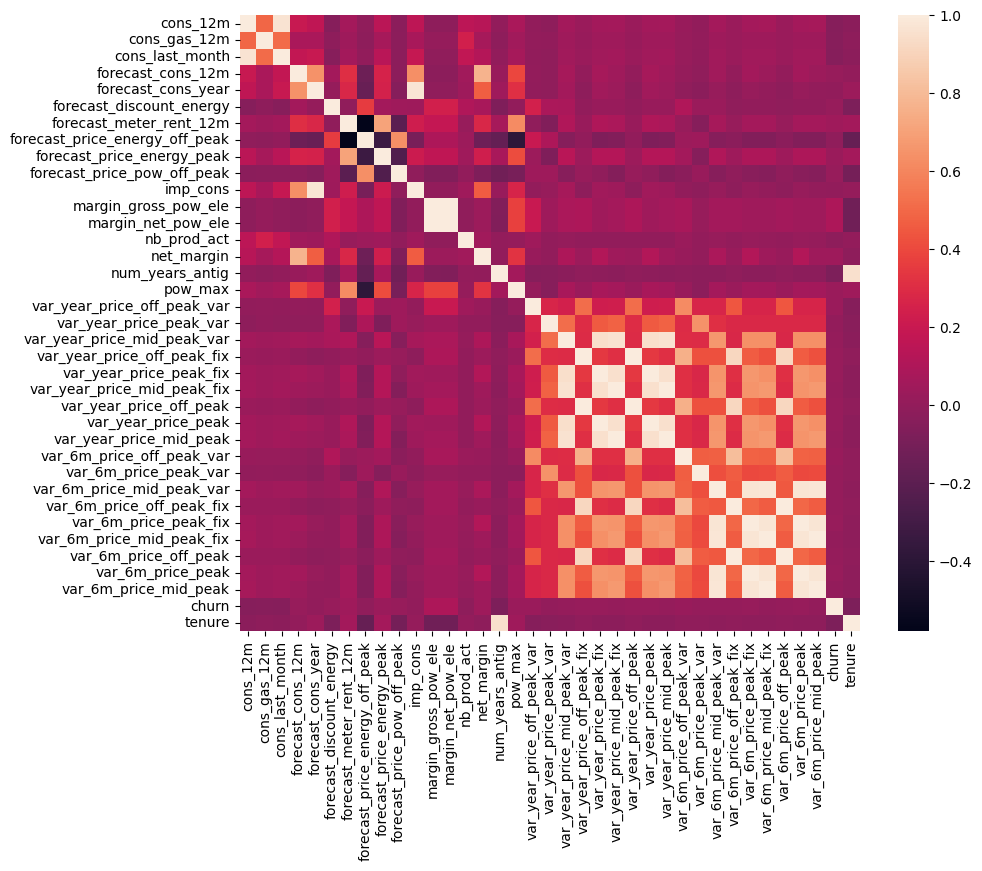

                                   churn
cons_12m                       -0.045968
cons_gas_12m                   -0.037957
cons_last_month                -0.045284
forecast_cons_12m               0.012949
forecast_cons_year             -0.002558
forecast_discount_energy        0.017026
forecast_meter_rent_12m         0.044245
forecast_price_energy_off_peak -0.010837
forecast_price_energy_peak      0.029315
forecast_price_pow_off_peak     0.014778
imp_cons                       -0.001583
margin_gross_pow_ele            0.095725
margin_net_pow_ele              0.095772
nb_prod_act                    -0.014930
net_margin                      0.041135
num_years_antig                -0.074140
pow_max                         0.030362
var_year_price_off_peak_var     0.028646
var_year_price_peak_var         0.006274
var_year_price_mid_peak_var     0.010415
var_year_price_off_peak_fix     0.018930
var_year_price_peak_fix         0.014674
var_year_price_mid_peak_fix     0.007956
var_year_price_o

In [ ]:
def convert_to_float(column):
    return pd.to_numeric(column, errors='coerce')

# Apply conversion to all columns that are of object (string) type
client_df = client_df.apply(lambda col: convert_to_float(col) if col.dtype == 'object' else col)


client_df.drop(columns=["id", "channel_sales", "has_gas", "origin_up", "date_activ", "date_end", "date_modif_prod", "date_renewal"], inplace=True)


# Calculate the correlation matrix
correlation_matrix = client_df.corr()

# Plot the correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix)
plt.show()

# Check correlation of each feature with 'churn'
client_df = pd.DataFrame(correlation_matrix['churn'])
print(client_df)

# computation of correlation matrix and droping of unwanted columns from the price_data.

                    price_off_peak_var  price_peak_var  price_mid_peak_var  \
price_off_peak_var            1.000000       -0.328580           -0.594872   
price_peak_var               -0.328580        1.000000            0.821353   
price_mid_peak_var           -0.594872        0.821353            1.000000   
price_off_peak_fix            0.417097       -0.098627           -0.137848   
price_peak_fix               -0.630018        0.796097            0.973960   
price_mid_peak_fix           -0.572229        0.807759            0.979717   
diff_off_peak                -0.413264        0.097294            0.135356   
diff_peak                     0.630690       -0.794667           -0.973778   
diff_mid_peak                 0.572068       -0.807618           -0.979528   

                    price_off_peak_fix  price_peak_fix  price_mid_peak_fix  \
price_off_peak_var            0.417097       -0.630018           -0.572229   
price_peak_var               -0.098627        0.796097         

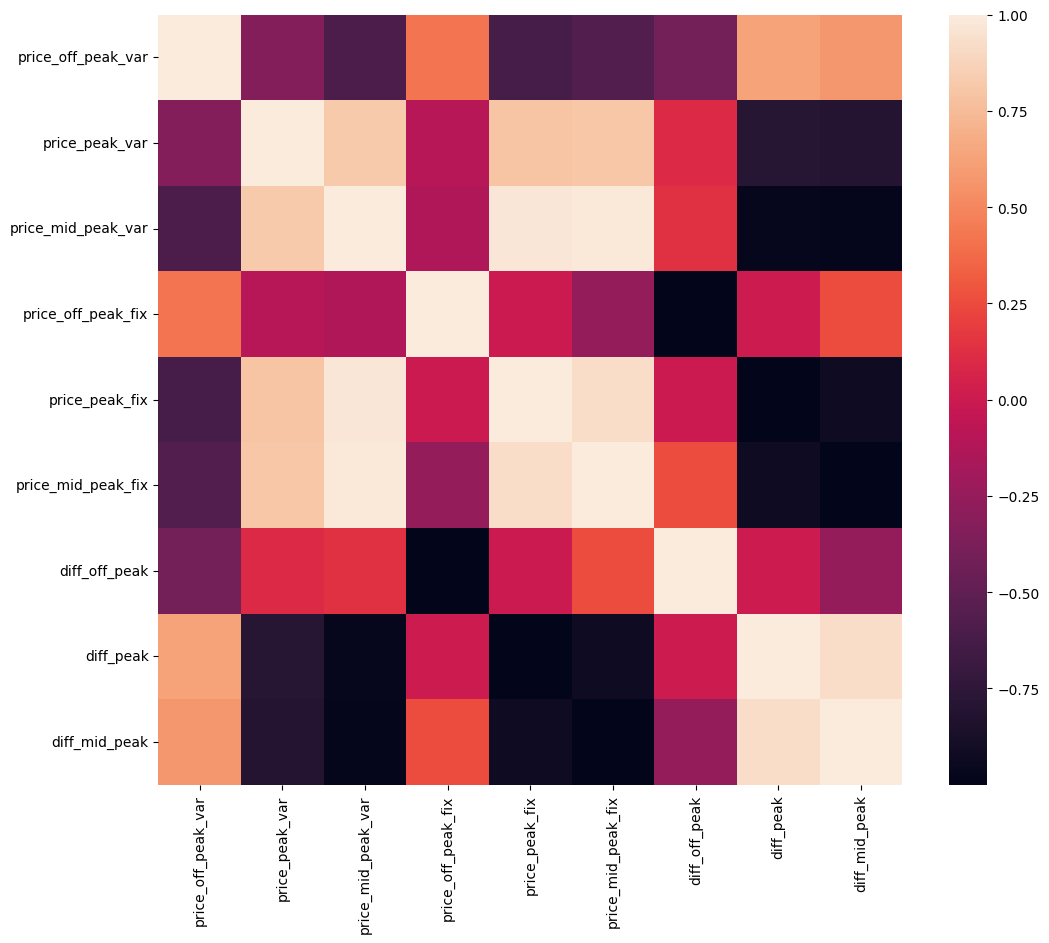

In [ ]:
price_df.drop(columns=["id", "price_date"], inplace=True)
# Compute the correlation matrix for price_data
correlation_matrix = price_df.corr()
print(correlation_matrix)
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, fmt=".2f")
plt.show()
